In [1]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.offline import iplot , plot
import plotly.io as pio
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)
from plotly.subplots import make_subplots
from sklearn.preprocessing import MinMaxScaler , LabelEncoder
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier , GradientBoostingClassifier , BaggingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
#from xgboost import XGBClassifier
from sklearn.metrics import  ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load and prepare the data
data = pd.read_csv('/Users/Garima/Predictive/data/alzheimers_prediction_dataset.csv')

# 1. Exploratory Data Analysis

# Basic information about the dataset
print("Dataset Info:")
print(data.info())
print("\nDescriptive Statistics:")
print(data.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74283 entries, 0 to 74282
Data columns (total 25 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Country                               74283 non-null  object 
 1   Age                                   74283 non-null  int64  
 2   Gender                                74283 non-null  object 
 3   Education Level                       74283 non-null  int64  
 4   BMI                                   74283 non-null  float64
 5   Physical Activity Level               74283 non-null  object 
 6   Smoking Status                        74283 non-null  object 
 7   Alcohol Consumption                   74283 non-null  object 
 8   Diabetes                              74283 non-null  object 
 9   Hypertension                          74283 non-null  object 
 10  Cholesterol Level                     74283 non-null  object 
 11  F

In [5]:
# Show Shape of Data
print(f"Number of Row : {data.shape[0]}\nNumber of Columns : {data.shape[1]}")

Number of Row : 74283
Number of Columns : 25


In [7]:
data.isna().sum()

Country                                 0
Age                                     0
Gender                                  0
Education Level                         0
BMI                                     0
Physical Activity Level                 0
Smoking Status                          0
Alcohol Consumption                     0
Diabetes                                0
Hypertension                            0
Cholesterol Level                       0
Family History of Alzheimer’s           0
Cognitive Test Score                    0
Depression Level                        0
Sleep Quality                           0
Dietary Habits                          0
Air Pollution Exposure                  0
Employment Status                       0
Marital Status                          0
Genetic Risk Factor (APOE-ε4 allele)    0
Social Engagement Level                 0
Income Level                            0
Stress Levels                           0
Urban vs Rural Living             

In [9]:
# Describe Numeric Data
data.describe()

,Age,Education Level,BMI,Cognitive Test Score
count,74283.000000,74283.000000,74283.000000,74283.000000
mean,71.964703,9.487514,26.780639,64.654241
std,12.980748,5.757020,4.764679,20.153247
min,50.000000,0.000000,18.500000,30.000000
25%,61.000000,4.000000,22.700000,47.000000
50%,72.000000,9.000000,26.800000,65.000000
75%,83.000000,14.000000,30.900000,82.000000
max,94.000000,19.000000,35.000000,99.000000


In [11]:
# Describe non Numiric Data
data.describe(exclude='number').T

,count,unique,top,freq
Country,74283,20,Brazil,3839
Gender,74283,2,Female,37249
Physical Activity Level,74283,3,High,24853
Smoking Status,74283,3,Current,24915
Alcohol Consumption,74283,3,Never,24865
Diabetes,74283,2,No,59527
Hypertension,74283,2,No,52134
Cholesterol Level,74283,2,Normal,51973
Family History of Alzheimer’s,74283,2,No,52004
Depression Level,74283,3,Medium,24843


In [13]:
pd.DataFrame({'Count':data.shape[0],
              'Null':data.isnull().sum(),
              'Null %':data.isnull().mean() * 100,
              'Cardinality':data.nunique()
})

,Count,Null,Null %,Cardinality
Country,74283,0,0.0,20
Age,74283,0,0.0,45
Gender,74283,0,0.0,2
Education Level,74283,0,0.0,20
BMI,74283,0,0.0,166
Physical Activity Level,74283,0,0.0,3
Smoking Status,74283,0,0.0,3
Alcohol Consumption,74283,0,0.0,3
Diabetes,74283,0,0.0,2
Hypertension,74283,0,0.0,2


In [15]:
# Check Duplication
data.duplicated().sum()

0

In [17]:
# Identify numerical columns: Columns with more than 10 unique values are considered numerical
numerical_columns =data.select_dtypes('number').columns.to_list()

In [19]:

# Identify categorical columns: Columns that are not numerical and not 'Alzheimer'
categorical_columns =data.select_dtypes(exclude = 'number').columns.to_list()
print(categorical_columns)

['Country', 'Gender', 'Physical Activity Level', 'Smoking Status', 'Alcohol Consumption', 'Diabetes', 'Hypertension', 'Cholesterol Level', 'Family History of Alzheimer’s', 'Depression Level', 'Sleep Quality', 'Dietary Habits', 'Air Pollution Exposure', 'Employment Status', 'Marital Status', 'Genetic Risk Factor (APOE-ε4 allele)', 'Social Engagement Level', 'Income Level', 'Stress Levels', 'Urban vs Rural Living', 'Alzheimer’s Diagnosis']


In [21]:
def detect_outliers_iqr(data, columns, threshold = 1.5):

    outlier_indices = {}

    for col in columns:
        Q1 = data[col].quantile(0.25)  # 25th percentile
        Q3 = data[col].quantile(0.75)  # 75th percentile
        IQR = Q3 - Q1  # Interquartile range
        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR

        # Finding outliers
        outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)].index.tolist()
        outlier_indices[col] = outliers
    
    return outlier_indices

numerical_columns =data.select_dtypes('number').columns.to_list()
outliers_iqr = detect_outliers_iqr(data, numerical_columns)

for col, indices in outliers_iqr.items():
    print(f"{col}: {len(indices)} outliers detected")

Age: 0 outliers detected
Education Level: 0 outliers detected
BMI: 0 outliers detected
Cognitive Test Score: 0 outliers detected


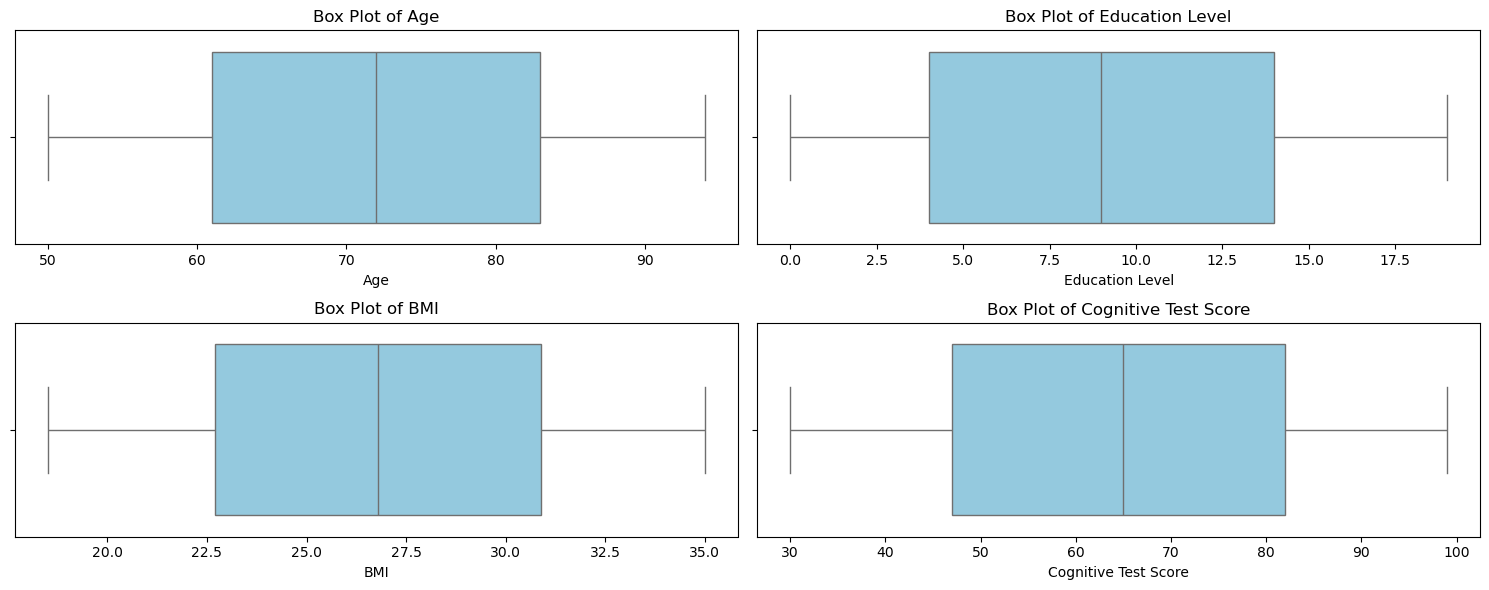

In [23]:
plt.figure(figsize=(15, 6))

for i, col in enumerate(numerical_columns, 1):
    plt.subplot(2, 2, i)  
    sns.boxplot(x = data[col], color = "skyblue")
    plt.title(f"Box Plot of {col}")

plt.tight_layout()
plt.show()

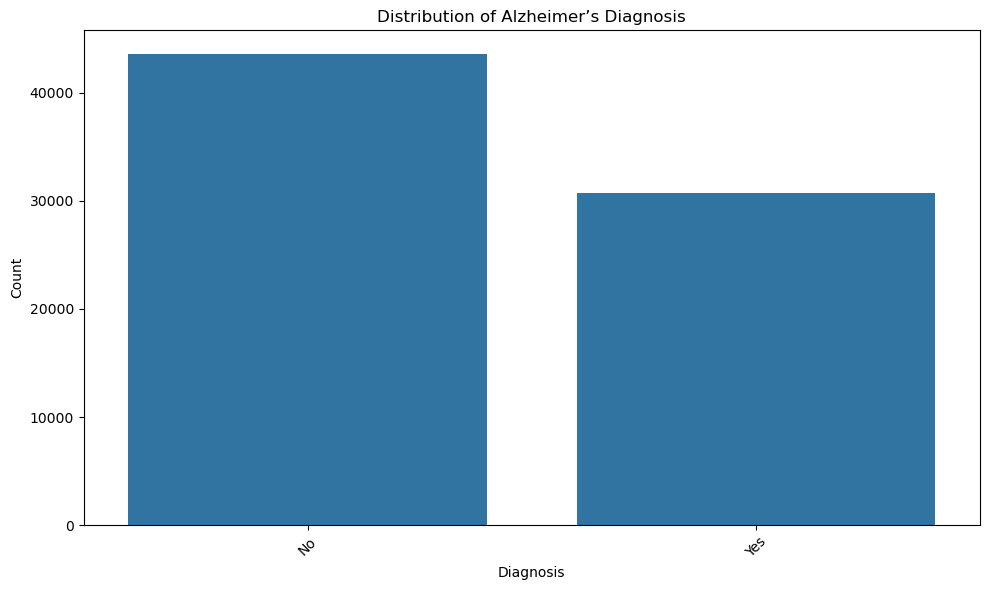


Class Distribution for Alzheimer’s Diagnosis:


Alzheimer’s Diagnosis
No     58.65%
Yes    41.35%
Name: proportion, dtype: object

In [24]:
### Target Variable Distribution
target_column = 'Alzheimer’s Diagnosis'

plt.figure(figsize=(10, 6))
diagnosis_counts = data[target_column].value_counts()
sns.barplot(x=diagnosis_counts.index, y=diagnosis_counts.values)
plt.title(f'Distribution of {target_column}')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"\nClass Distribution for {target_column}:")
data[target_column].value_counts(normalize=True).mul(100).round(2).astype(str) + '%'



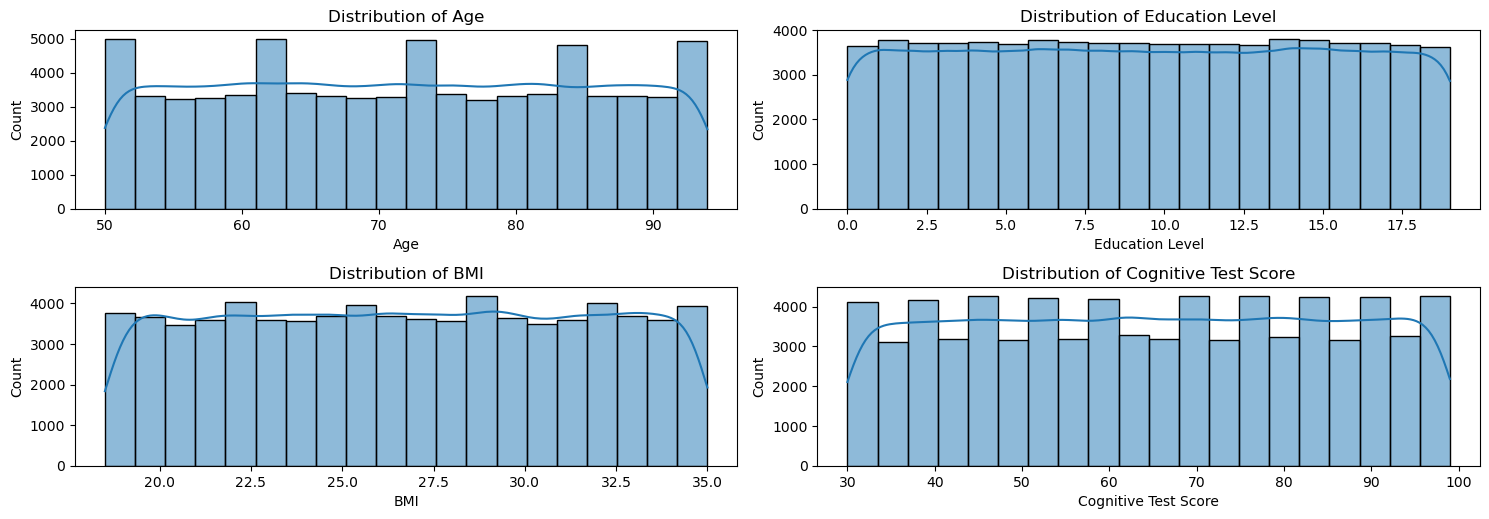

In [26]:
numeric_cols = numerical_columns

# Plot histograms
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(4, 2, i+1)
    sns.histplot(data[col], bins=20, kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

### Distribution of Categorical Features

In [30]:
## Alzheimer Diagnosis by country
fig = px.bar(data['Country'][data['Alzheimer’s Diagnosis'] == 'Yes'].value_counts(),
             color = data['Country'][data['Alzheimer’s Diagnosis'] == 'Yes'].value_counts().index,
             template = 'plotly_white',
             title = 'Most Country has Alzheimer’s Diagnosis',
             labels = {'value':'Count'},
             text_auto = True
             )
pio.renderers.default = 'iframe'
fig.show()

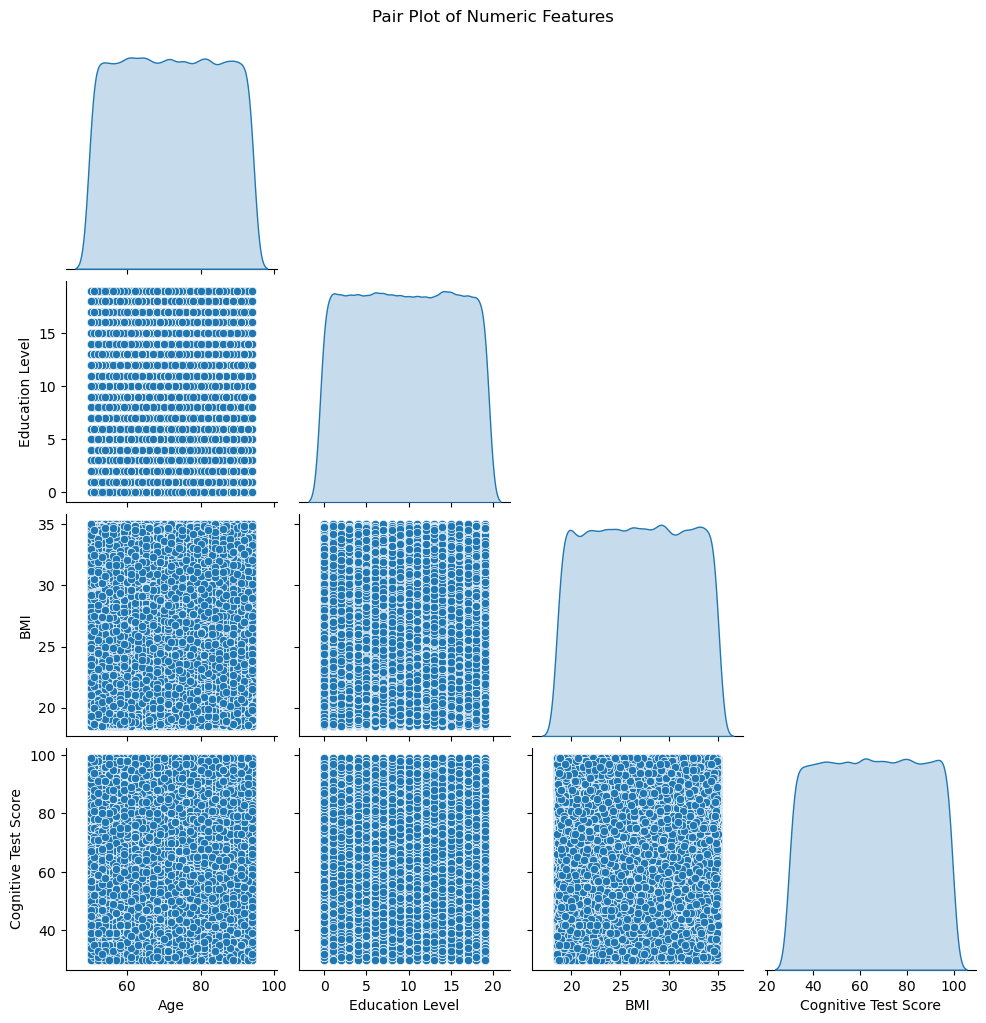

In [32]:
sns.pairplot(data, diag_kind='kde', corner=True)
plt.suptitle('Pair Plot of Numeric Features', y=1.02)
plt.show()

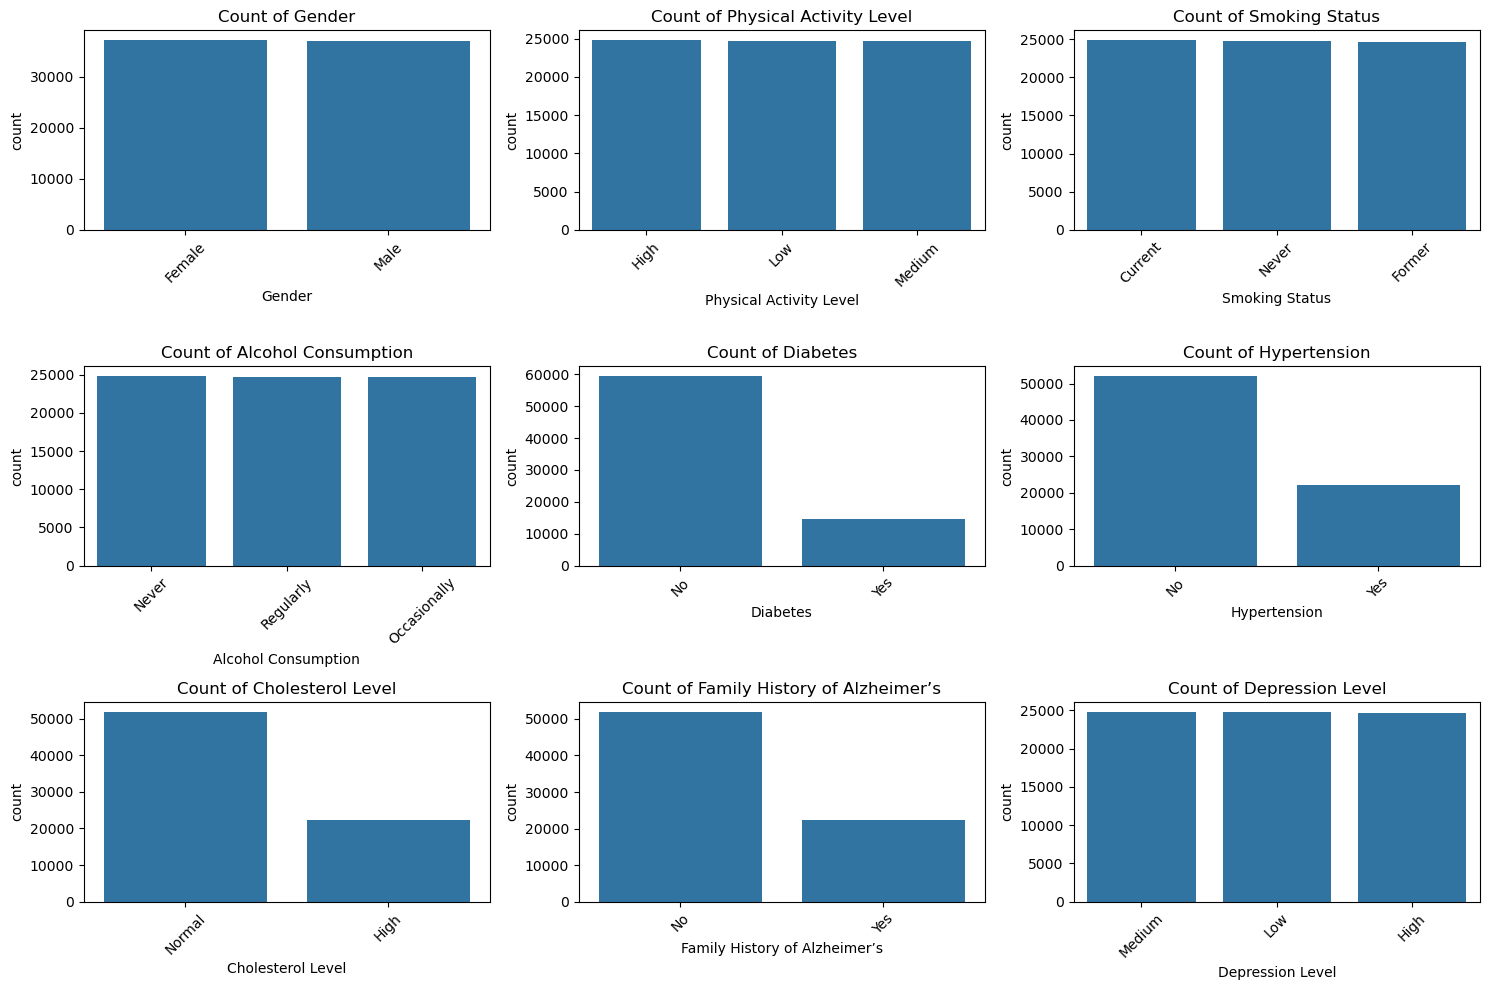

In [33]:
categorical_cols = [ 'Gender', 
                    'Physical Activity Level', 'Smoking Status', 'Alcohol Consumption', 'Diabetes', 'Hypertension', 
                    'Cholesterol Level', 'Family History of Alzheimer’s', 'Depression Level', 'Sleep Quality', 'Dietary Habits', 
                    'Air Pollution Exposure', 'Employment Status', 'Marital Status', 'Genetic Risk Factor (APOE-ε4 allele)', 
                    'Social Engagement Level', 'Income Level', 'Stress Levels', 'Urban vs Rural Living', 'Alzheimer’s Diagnosis']

plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols[:9]):
    plt.subplot(3, 3, i + 1)
    sns.countplot(x=data[col], order=data[col].value_counts().index)
    plt.xticks(rotation=45)
    plt.title(f'Count of {col}')
plt.tight_layout()
plt.show()

In [40]:
# Let's see relation between Alzheiermer diagnosis and Depression level
crstab_dep_alzh = pd.crosstab(data['Alzheimer’s Diagnosis'], data["Depression Level"], margins =  True)
crstab_dep_alzh

Depression Level,High,Low,Medium,All
Alzheimer’s Diagnosis,,,,
No,14446,14505,14619,43570
Yes,10236,10253,10224,30713
All,24682,24758,24843,74283


#### Our of 24682 people having high depression, 10236 people are diagnosed with Alzheimer. Out of 74283 people, 30713 are Alzheimer positive,

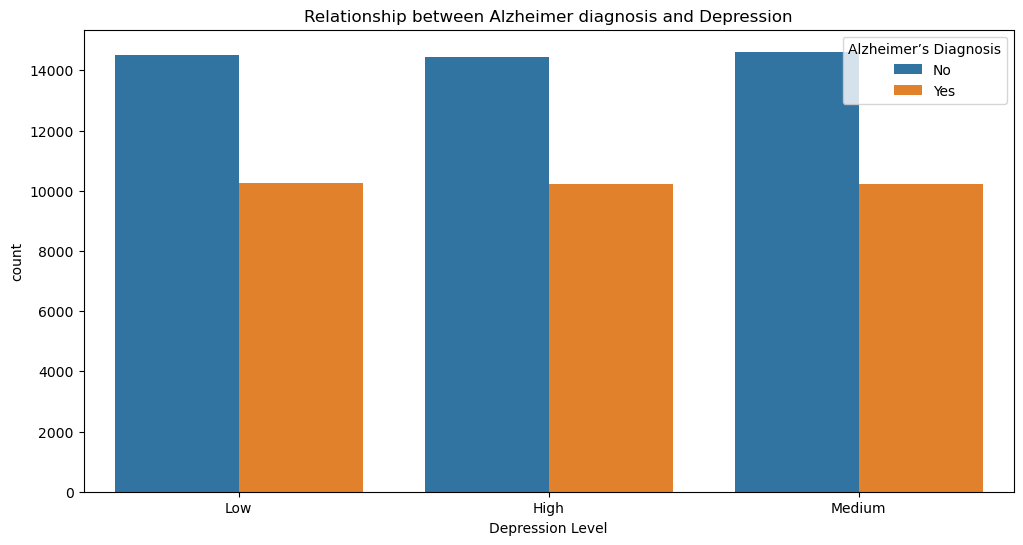

In [43]:
# Plot the relationship between Alzheimer diagnosis and Depression level
plt.figure(figsize=(12,6))
sns.countplot(data, x = 'Depression Level', hue = 'Alzheimer’s Diagnosis')
plt.title('Relationship between Alzheimer diagnosis and Depression')
plt.show()

In [45]:
# Relation between Alzheimer's diagnosis and Stress level
crstab_stress =  pd.crosstab(data['Alzheimer’s Diagnosis'], data['Stress Levels'], margins = True)
crstab_stress

Stress Levels,High,Low,Medium,All
Alzheimer’s Diagnosis,,,,
No,14378,14546,14646,43570
Yes,10289,10184,10240,30713
All,24667,24730,24886,74283


#### Out of 24667 people with high stress level, 10289 people have alzheimer.

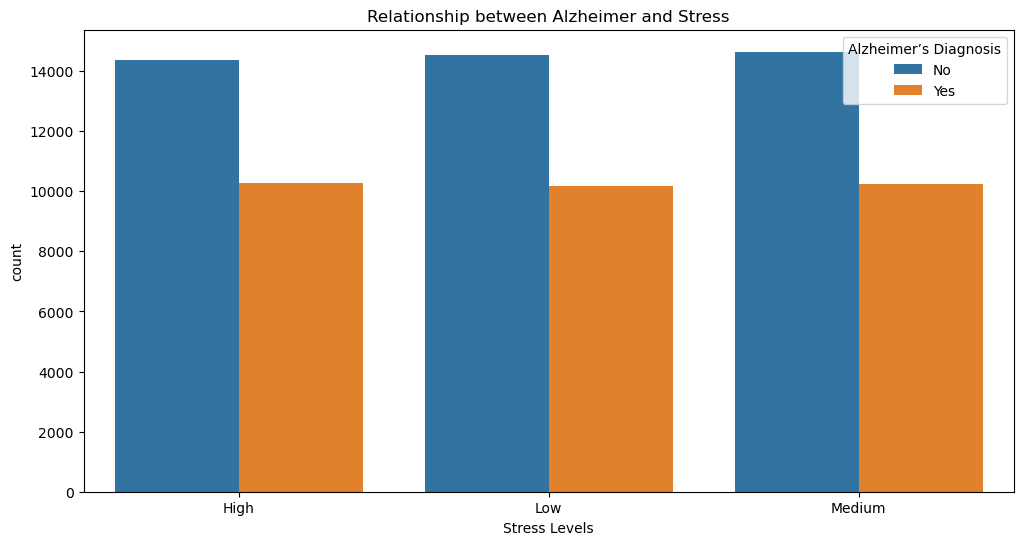

In [48]:
# Plot the relationship between Alzheimer diagnosis and Stress level
plt.figure(figsize=(12,6))
sns.countplot(data, x = 'Stress Levels', hue = 'Alzheimer’s Diagnosis')
plt.title('Relationship between Alzheimer and Stress')
plt.show()

In [50]:
# Relation between Dietary habits and Alzheimer
crstab_diet = pd.crosstab(data['Alzheimer’s Diagnosis'], data['Dietary Habits'])
crstab_diet

Dietary Habits,Average,Healthy,Unhealthy
Alzheimer’s Diagnosis,,,
No,14636,14535,14399
Yes,10281,10153,10279


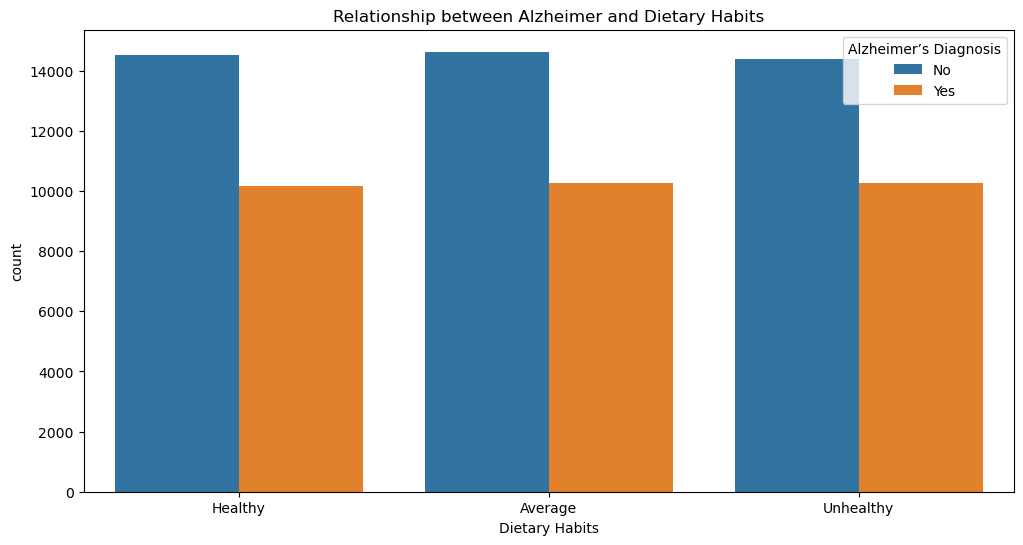

In [52]:
# Plot the relationship between Alzheimer diagnosis and Dietary Habits
plt.figure(figsize=(12,6))
sns.countplot(data, x = 'Dietary Habits', hue = 'Alzheimer’s Diagnosis')
plt.title('Relationship between Alzheimer and Dietary Habits')
plt.show()

In [54]:

# Relation between Alzheimer and Family History
crstab_family = pd.crosstab(data['Alzheimer’s Diagnosis'], data['Family History of Alzheimer’s'], margins =  True)
crstab_family

Family History of Alzheimer’s,No,Yes,All
Alzheimer’s Diagnosis,,,
No,32864,10706,43570
Yes,19140,11573,30713
All,52004,22279,74283


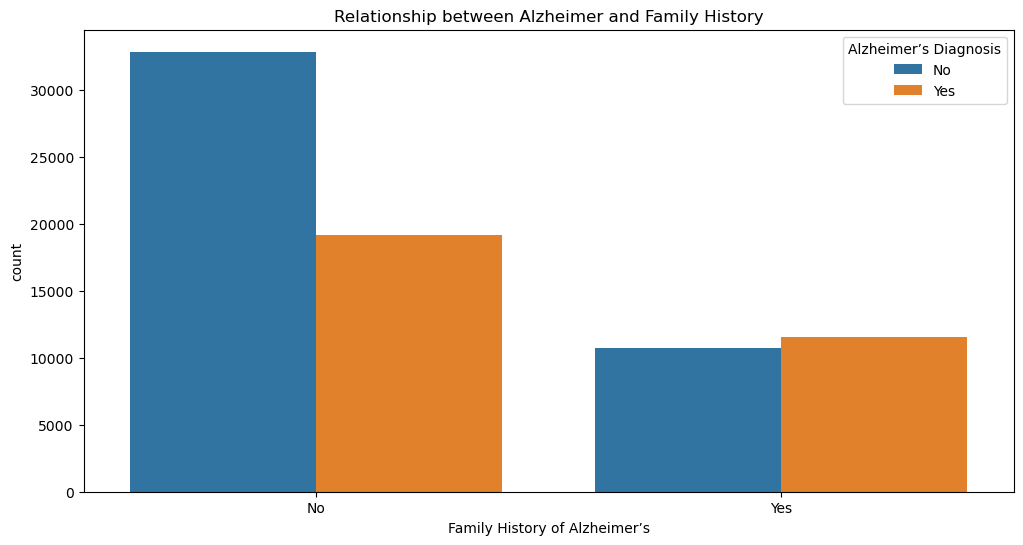

In [56]:
# Plot the relationship between Alzheimer diagnosis and Family History
plt.figure(figsize=(12,6))
sns.countplot(data, x = 'Family History of Alzheimer’s', hue = 'Alzheimer’s Diagnosis')
plt.title('Relationship between Alzheimer and Family History')
plt.show()

In [58]:
# Relation between Alzheimer's Diagnosis and Hypertension
crstab_hypertension = pd.crosstab(data['Alzheimer’s Diagnosis'], data['Hypertension'], margins =  True)
crstab_hypertension

Hypertension,No,Yes,All
Alzheimer’s Diagnosis,,,
No,30559,13011,43570
Yes,21575,9138,30713
All,52134,22149,74283


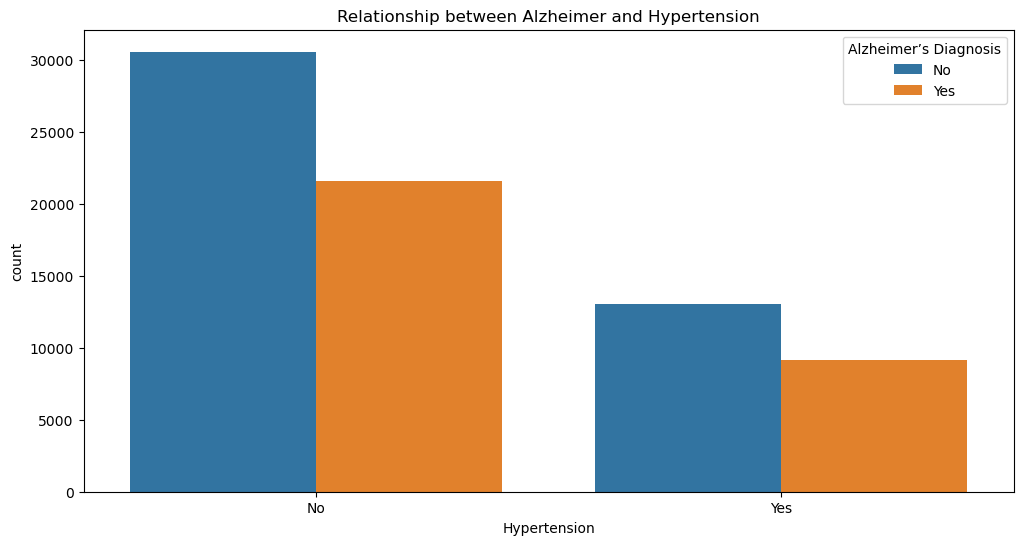

In [60]:
# Plot the relationship between Alzheimer diagnosis and HyperTension
plt.figure(figsize=(12,6))
sns.countplot(data, x = 'Hypertension', hue = 'Alzheimer’s Diagnosis')
plt.title('Relationship between Alzheimer and Hypertension')
plt.show()

In [62]:
# Relation between Alzheimer's Diagnosis and Alcohol Consumption
crstab_alcohol = pd.crosstab(data['Alzheimer’s Diagnosis'], data['Alcohol Consumption'], margins =  True)
crstab_alcohol

Alcohol Consumption,Never,Occasionally,Regularly,All
Alzheimer’s Diagnosis,,,,
No,14659,14380,14531,43570
Yes,10206,10300,10207,30713
All,24865,24680,24738,74283


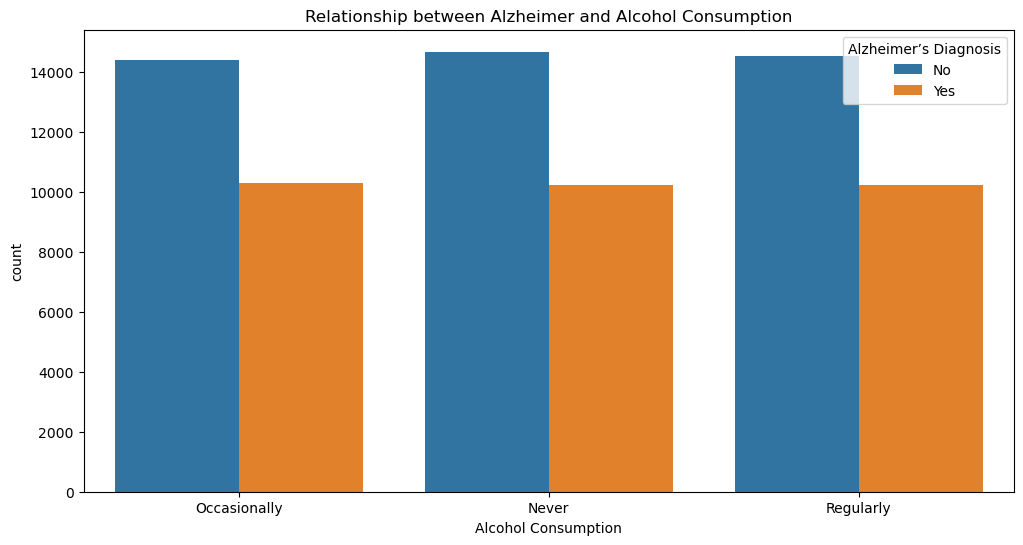

In [64]:
# Plot the relationship between Alzheimer diagnosis and Alcohol consumption
plt.figure(figsize=(12,6))
sns.countplot(data, x = 'Alcohol Consumption', hue = 'Alzheimer’s Diagnosis')
plt.title('Relationship between Alzheimer and Alcohol Consumption')
plt.show()

In [66]:
# Relation between Alzheimer's Diagnosis and Diabetes
crstab_diabetes = pd.crosstab(data['Alzheimer’s Diagnosis'], data['Diabetes'], margins =  True)
crstab_diabetes

Diabetes,No,Yes,All
Alzheimer’s Diagnosis,,,
No,34876,8694,43570
Yes,24651,6062,30713
All,59527,14756,74283


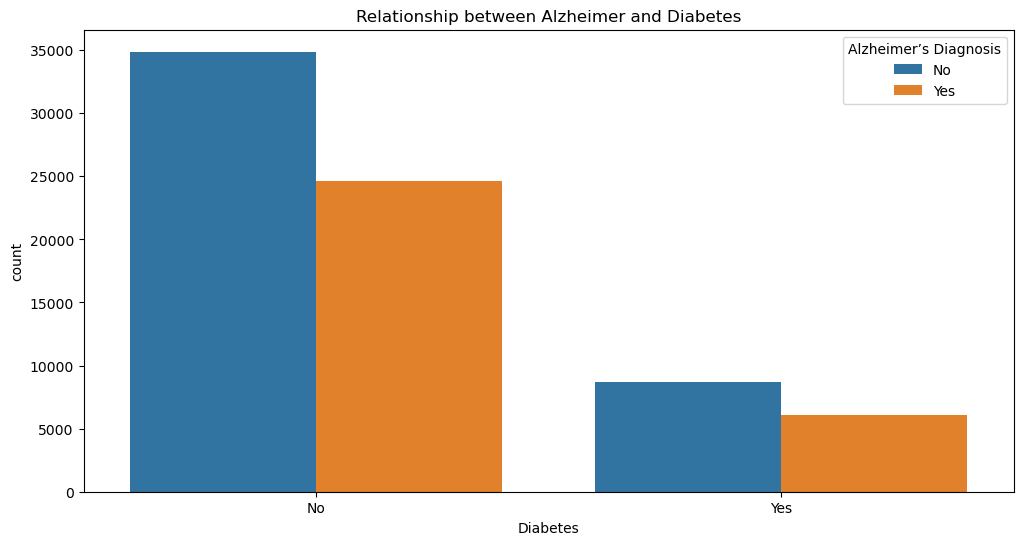

In [68]:

# Plot the relationship between Alzheimer diagnosis and Diabetes
plt.figure(figsize=(12,6))
sns.countplot(data, x = 'Diabetes', hue = 'Alzheimer’s Diagnosis')
plt.title('Relationship between Alzheimer and Diabetes')
plt.show()

In [70]:
# Relation between Alzheimer's Diagnosis and Smoking Status
crstab_smoking = pd.crosstab(data['Alzheimer’s Diagnosis'], data['Smoking Status'], margins =  True)
crstab_smoking

Smoking Status,Current,Former,Never,All
Alzheimer’s Diagnosis,,,,
No,14658,14467,14445,43570
Yes,10257,10161,10295,30713
All,24915,24628,24740,74283


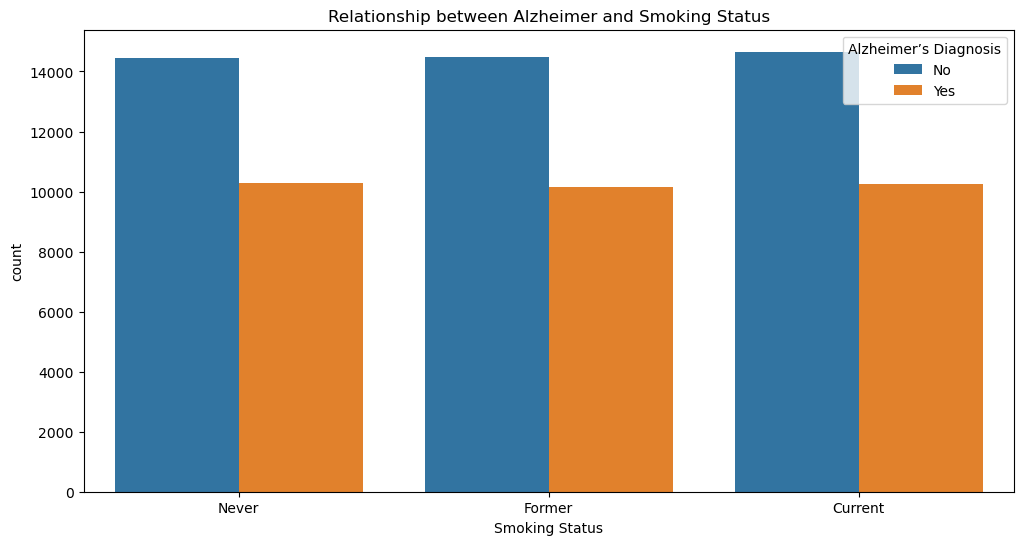

In [72]:
# Plot the relationship between Alzheimer diagnosis and Smoking
plt.figure(figsize=(12,6))
sns.countplot(data, x = 'Smoking Status', hue = 'Alzheimer’s Diagnosis')
plt.title('Relationship between Alzheimer and Smoking Status')
plt.show()

In [74]:
# Relation between Alzheimer's Diagnosis and Physical Activity Level
crstab_physical = pd.crosstab(data['Alzheimer’s Diagnosis'], data['Physical Activity Level'], margins =  True)
crstab_physical

Physical Activity Level,High,Low,Medium,All
Alzheimer’s Diagnosis,,,,
No,14525,14536,14509,43570
Yes,10328,10218,10167,30713
All,24853,24754,24676,74283


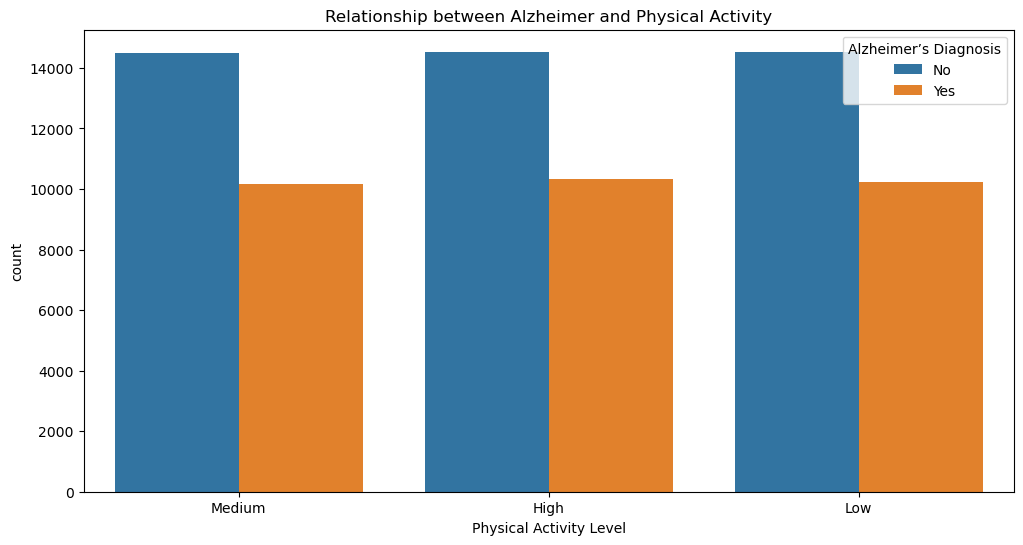

In [76]:
# Plot the relationship between Alzheimer diagnosis and Physical Activity
plt.figure(figsize=(12,6))
sns.countplot(data, x = 'Physical Activity Level', hue = 'Alzheimer’s Diagnosis')
plt.title('Relationship between Alzheimer and Physical Activity')
plt.show()

In [78]:
# Relation between Alzheimer's Diagnosis and Cholesterol Level
crstab_ch = pd.crosstab(data['Alzheimer’s Diagnosis'], data['Cholesterol Level'], margins =  True)
crstab_ch

Cholesterol Level,High,Normal,All
Alzheimer’s Diagnosis,,,
No,13121,30449,43570
Yes,9189,21524,30713
All,22310,51973,74283


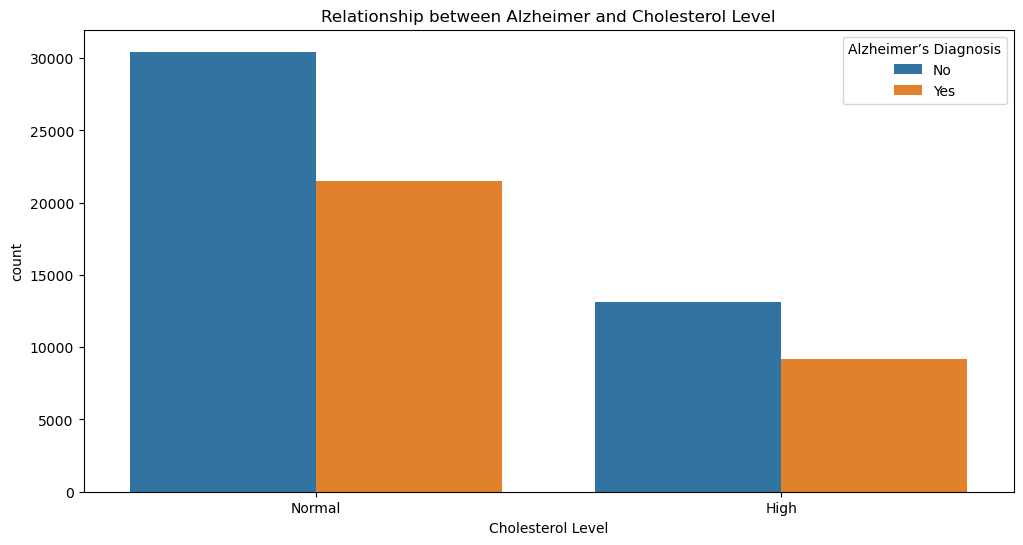

In [80]:
# Plot the relationship between Alzheimer diagnosis and Cholesterol level
plt.figure(figsize=(12,6))
sns.countplot(data, x = 'Cholesterol Level', hue = 'Alzheimer’s Diagnosis')
plt.title('Relationship between Alzheimer and Cholesterol Level')
plt.show()

### We have visualized and explored all features potentially related to Alzheimer.

## Machine Learning Modeling

In [ ]:
# Splitting into features and target variable
X = data.drop(columns=['Alzheimer’s Diagnosis','Country','Marital Status','Income Level','Employment Status'])
y = data['Alzheimer’s Diagnosis']
print("\n Dimension of X: \n", X.shape)
print("\n Dimension of y: \n", y.shape)

In [ ]:
# Encoding Categorical variable
categorical_columns = data.select_dtypes(include=['object']).columns
categorical_columns
print(categorical_columns.shape)

In [ ]:
cat_cols = ['Gender','Physical Activity Level','Smoking Status','Alcohol Consumption','Diabetes',
           'Hypertension','Cholesterol Level','Family History of Alzheimer’s','Depression Level',
           'Sleep Quality','Dietary Habits','Air Pollution Exposure','Genetic Risk Factor (APOE-ε4 allele)',
           'Social Engagement Level','Stress Levels','Urban vs Rural Living']
len(cat_cols)

In [ ]:
# Label Encoding cat_cols
label_encoder = LabelEncoder()
X[cat_cols] = X[cat_cols].apply(label_encoder.fit_transform)
print(X.shape)
print(X.head())

In [ ]:
# let's dervive correlation matrix and try to identify the correlation among features
# Correlation between features
corr_matrix = X.corr()
# Step 4: Plot the correlation heatmap for features
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f', vmin=-1, vmax=1)
plt.title("Correlation Heatmap of Features (Excluding Target)", fontsize=16)
plt.show()
print(X.shape)

### There is no much correlation among features so there seems no redundancy.

# Model Evaluation

In [ ]:
# Split into training and testing set
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size =0.2, random_state = 40)
print(f"Training set shape: X_train = {X_train.shape}, y_train = {y_train.shape}")
print(f"Test set shape: X_test = {X_test.shape}, y_test = {y_test.shape}")

In [ ]:
# Initialize model
rfc = RandomForestClassifier(n_estimators = 100, random_state = 42)

In [ ]:
# Fit model
rfc.fit(X_train, y_train)

In [ ]:
# make predictions on testing set
y_pred = rfc.predict(X_test)

In [ ]:
# Evaluate model
# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Step 8: Plotting the Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Yes', 'No'], yticklabels=['Yes', 'No'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [ ]:
model = LogisticRegression(class_weight='balanced' , max_iter=1000 , random_state=42)
model.fit(X_train, y_train)

In [ ]:
model.score(X_test, y_test)*100

In [ ]:
model.score(X_train, y_train)*100

In [ ]:
# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Step 8: Plotting the Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Yes', 'No'], yticklabels=['Yes', 'No'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [84]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data.drop(columns="Alzheimer’s Diagnosis"),
                                                    data["Alzheimer’s Diagnosis"],
                                                    test_size=0.20,
                                                    random_state=42)

X_train.shape, X_test.shape

((59426, 24), (14857, 24))

In [86]:
categorical_features = [feature for feature in X_train.columns if X_train[feature].dtypes == "O"]
numerical_features = [feature for feature in X_train.columns if X_train[feature].dtypes != "O"]

In [88]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder

ohe = OneHotEncoder(drop='first')
y_hat_encoder = LabelEncoder()

In [90]:
from sklearn.compose import ColumnTransformer

traf = ColumnTransformer([
    ("ohe", OneHotEncoder(drop='first'), categorical_features)
], remainder='passthrough')

X_train_trf = traf.fit_transform(X_train).toarray()
X_test_trf = traf.transform(X_test).toarray()

In [94]:
X_train_trf = traf.fit_transform(X_train).toarray()
X_test_trf = traf.transform(X_test).toarray()

In [96]:
y_train_encoded = y_hat_encoder.fit_transform(y_train)
y_test_encoded = y_hat_encoder.fit_transform(y_test)

              precision    recall  f1-score   support

           0       0.78      0.75      0.77      9158
           1       0.62      0.67      0.65      5699

    accuracy                           0.72     14857
   macro avg       0.70      0.71      0.71     14857
weighted avg       0.72      0.72      0.72     14857

Precision socre 0.6223525578364288
Precision socre 0.6702930338655905
Accuracy 0.717506899104799


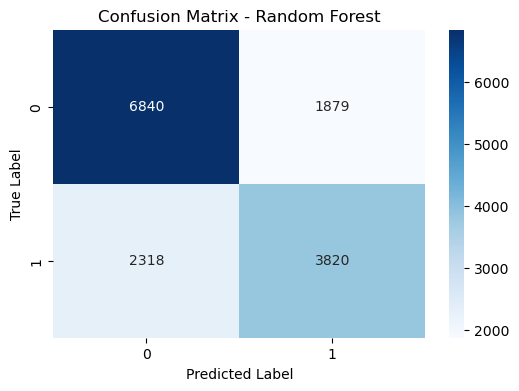

In [118]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train_trf, y_train_encoded)


y_pred = rf.predict(X_test_trf)

from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, accuracy_score
print(classification_report(y_pred, y_test_encoded))
print("Precision socre", precision_score(y_pred, y_test_encoded))
print("Precision socre", recall_score(y_pred, y_test_encoded))
print("Accuracy", accuracy_score(y_pred, y_test_encoded))

# Compute confusion matrix
cm = confusion_matrix(y_test_encoded, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=set(y_test_encoded), yticklabels=set(y_test_encoded))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Random Forest')
plt.show()

### There is misclassification of data to overcome that we are using oversampling techninque which is SMOTE

Class distribution after SMOTE: Counter({0: 34851, 1: 34851})
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.76      0.76      8719
           1       0.66      0.66      0.66      6138

    accuracy                           0.72     14857
   macro avg       0.71      0.71      0.71     14857
weighted avg       0.72      0.72      0.72     14857

Precision Score: 0.7199161208303007
Recall Score: 0.7201992326849297
Accuracy: 0.7201992326849297


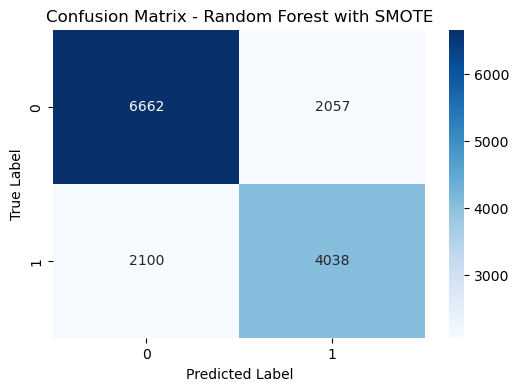

In [125]:
# Import necessary libraries
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Apply SMOTE to balance classes
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_trf, y_train_encoded)

# Check the class distribution after SMOTE
print("Class distribution after SMOTE:", Counter(y_train_resampled))

# Step 2: Train the Random Forest model
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf.fit(X_train_resampled, y_train_resampled)

# Step 3: Make predictions
y_pred = rf.predict(X_test_trf)

# Step 4: Evaluate model performance
print("Classification Report:\n", classification_report(y_test_encoded, y_pred))
print("Precision Score:", precision_score(y_test_encoded, y_pred, average='weighted'))
print("Recall Score:", recall_score(y_test_encoded, y_pred, average='weighted'))
print("Accuracy:", accuracy_score(y_test_encoded, y_pred))

# Step 5: Compute and plot the confusion matrix
cm = confusion_matrix(y_test_encoded, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Random Forest with SMOTE')
plt.show()


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, accuracy_score
print(classification_report(y_pred, y_test_encoded))
print("Precision socre", precision_score(y_pred, y_test_encoded))
print("Precision socre", recall_score(y_pred, y_test_encoded))
print("Accuracy", accuracy_score(y_pred, y_test_encoded))

# Compute confusion matrix
cm = confusion_matrix(y_test_encoded, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=set(y_test_encoded), yticklabels=set(y_test_encoded))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Random Forest')
plt.show()

              precision    recall  f1-score   support

           0       0.76      0.75      0.76      8843
           1       0.65      0.66      0.65      6014

    accuracy                           0.72     14857
   macro avg       0.70      0.71      0.71     14857
weighted avg       0.72      0.72      0.72     14857

Precision socre 0.6451612903225806
Precision socre 0.6584635849684071
Accuracy 0.7151511072221848


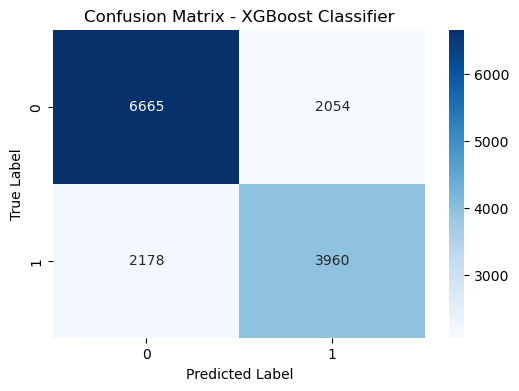

In [120]:
from xgboost import XGBClassifier


# Initialize the XGBoost classifier
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')

# Fit the model on the training data
xgb.fit(X_train_trf, y_train_encoded)

# Make predictions on the test data
y_pred = xgb.predict(X_test_trf)


# Evaluate the accuracy of the model
accuracy = accuracy_score(y_test_encoded, y_pred)
print(classification_report(y_pred, y_test_encoded))
print("Precision socre", precision_score(y_pred, y_test_encoded))
print("Precision socre", recall_score(y_pred, y_test_encoded))
print("Accuracy", accuracy_score(y_pred, y_test_encoded))

# Compute the confusion matrix
cm = confusion_matrix(y_test_encoded, y_pred)

# Plot confusion matrix as a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=set(y_test_encoded), yticklabels=set(y_test_encoded))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - XGBoost Classifier')
plt.show()

              precision    recall  f1-score   support

           0       0.80      0.73      0.76      9463
           1       0.59      0.67      0.63      5394

    accuracy                           0.71     14857
   macro avg       0.69      0.70      0.70     14857
weighted avg       0.72      0.71      0.71     14857

Precision score: 0.7218635986224536
Recall score: 0.7115164568890086
Accuracy: 0.7115164568890086


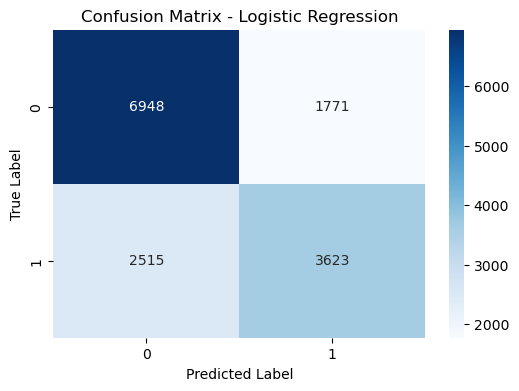

In [114]:
# Initialize and train the logistic regression model
lr = LogisticRegression()
lr.fit(X_train_trf, y_train_encoded)

# Make predictions on the test data
y_pred = lr.predict(X_test_trf)

# Compute evaluation metrics
accuracy = accuracy_score(y_test_encoded, y_pred)
print(classification_report(y_pred, y_test_encoded))
print("Precision score:", precision_score(y_pred, y_test_encoded, average='weighted'))
print("Recall score:", recall_score(y_pred, y_test_encoded, average='weighted'))
print("Accuracy:", accuracy)

# Compute and plot the confusion matrix
cm = confusion_matrix(y_test_encoded, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=set(y_test_encoded), yticklabels=set(y_test_encoded))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()